# Step 6: Results & Visualization - Comparing 2 Models
- Model 1: DistilBERT (ner_model_final)
- Model 2: BiLSTM+CRF Improved (bilstm_crf_improved.keras)

In [34]:
import json, ast, pandas as pd, numpy as np, matplotlib.pyplot as plt
from collections import Counter
import warnings
warnings.filterwarnings('ignore')

print("Loading data...")
df = pd.read_csv('D:/Python/NLP/CK/final_data.csv')
df['tokens'] = df['tokens'].apply(ast.literal_eval)
df['labels'] = df['labels'].apply(ast.literal_eval)
df = df[df['tokens'].apply(len) == df['labels'].apply(len)].reset_index(drop=True)
print(f"Loaded {len(df)} sentences")

with open('D:/Python/NLP/CK/label_mappings.json', 'r') as f:
    mappings = json.load(f)
    id2label = mappings['id2label']
    label2id = mappings['label2id']
print(f"Labels: {len(id2label)}")

Loading data...
Loaded 3113 sentences
Labels: 32


## Data Visualization

In [35]:
# Label Distribution
all_labels = []
for labels in df['labels']:
    all_labels.extend(labels)
label_counts = Counter(all_labels)
print("\nLabel Distribution:")
for label, count in label_counts.most_common():
    print(f"{label:<20} {count:>6}")


Label Distribution:
O                     84143
B-PERSON               2801
B-ORG                  2211
B-GPE                  1392
B-DATE                 1254
B-NORP                 1156
B-CARDINAL              730
I-PERSON                692
B-LOC                   684
I-ORG                   567
I-DATE                  399
I-MONEY                 361
B-MONEY                 277
B-ORDINAL               134
I-LOC                   122
I-GPE                   121
B-PRODUCT                91
B-WORK_OF_ART            73
I-NORP                   70
I-FAC                    63
B-FAC                    57
I-QUANTITY               52
B-QUANTITY               49
I-CARDINAL               44
I-WORK_OF_ART            29
B-TIME                   20
I-PRODUCT                18
B-LAW                    12
B-LANGUAGE                8
I-LAW                     4
I-ORDINAL                 2
I-TIME                    1


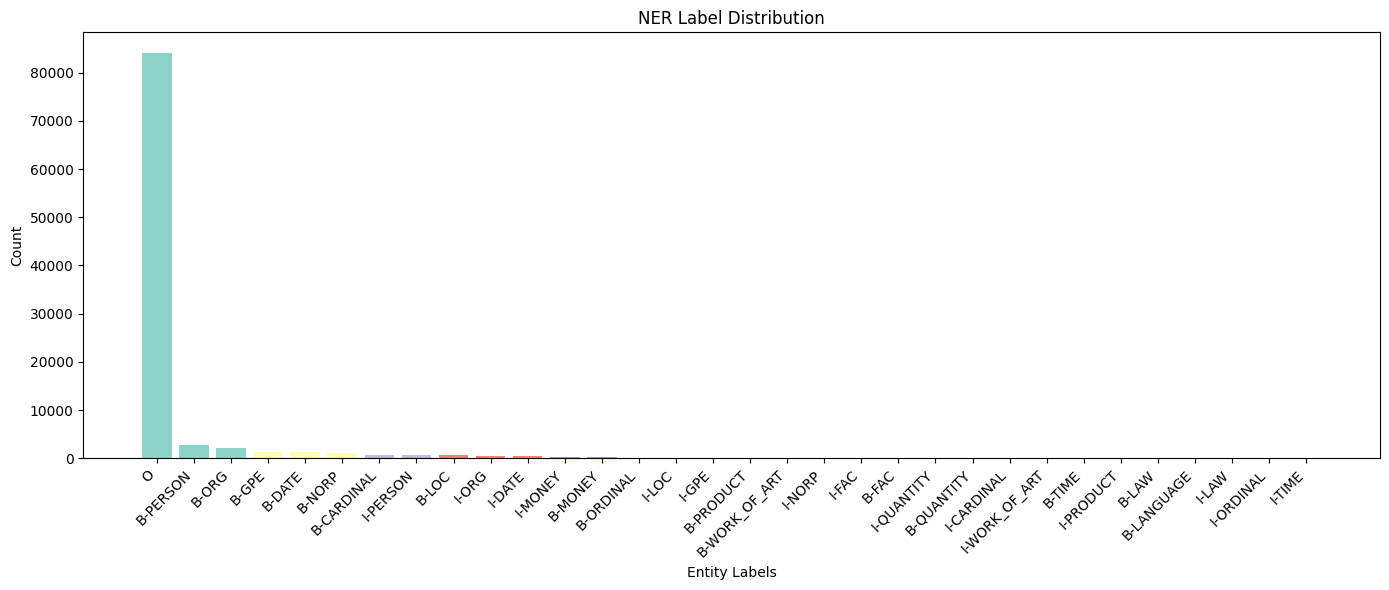

Saved: D:/Python/NLP/CK/charts/label_distribution.png


In [36]:
# Visualization - Label Distribution
plt.figure(figsize=(14, 6))
labels = list(label_counts.keys())
counts = list(label_counts.values())
sorted_idx = np.argsort(counts)[::-1]
labels = [labels[i] for i in sorted_idx]
counts = [counts[i] for i in sorted_idx]
colors = plt.cm.Set3(np.linspace(0, 1, len(labels)))
plt.bar(labels, counts, color=colors)
plt.xlabel('Entity Labels')
plt.ylabel('Count')
plt.title('NER Label Distribution')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.savefig('D:/Python/NLP/CK/charts/label_distribution.png', dpi=150)
plt.show()
print("Saved: D:/Python/NLP/CK/charts/label_distribution.png")

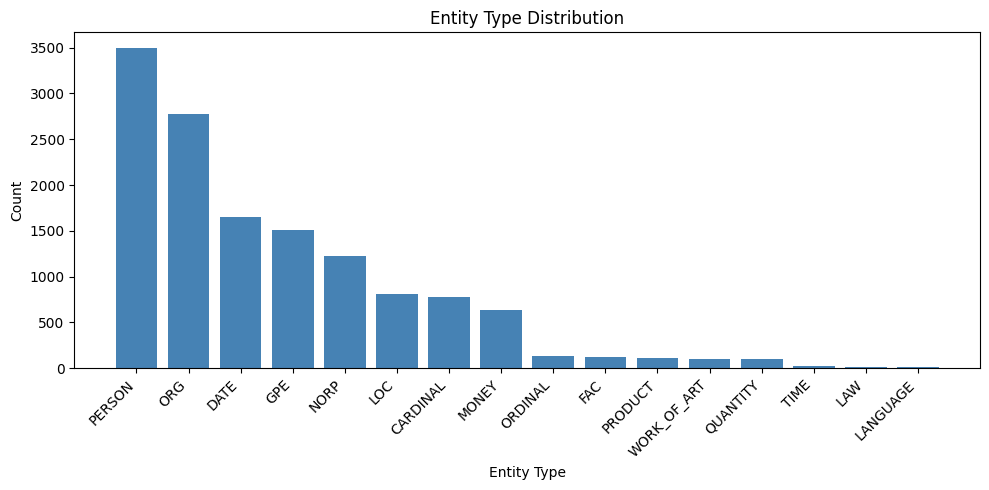

In [37]:
# Entity Type Summary
entity_counts = {}
for label, count in label_counts.items():
    if label == 'O': continue
    entity_type = label[2:] if label.startswith('B-') or label.startswith('I-') else label
    entity_counts[entity_type] = entity_counts.get(entity_type, 0) + count
entity_counts = dict(sorted(entity_counts.items(), key=lambda x: x[1], reverse=True))

plt.figure(figsize=(10, 5))
entities = list(entity_counts.keys())
counts = list(entity_counts.values())
plt.bar(entities, counts, color='steelblue')
plt.xlabel('Entity Type')
plt.ylabel('Count')
plt.title('Entity Type Distribution')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.savefig('D:/Python/NLP/CK/charts/entity_distribution.png', dpi=150)
plt.show()

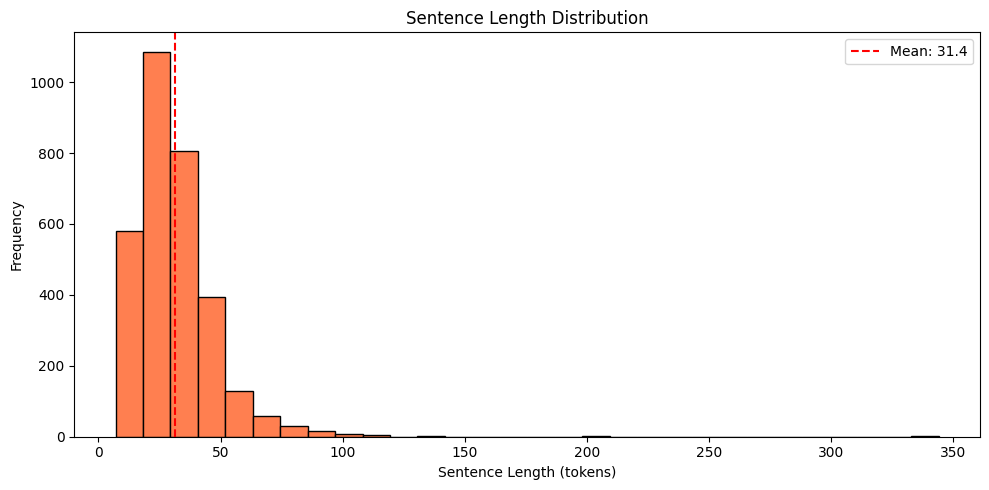

Mean: 31.36, Max: 344, Min: 7


In [38]:
# Sentence Length Distribution
sentence_lengths = df['tokens'].apply(len)
plt.figure(figsize=(10, 5))
plt.hist(sentence_lengths, bins=30, color='coral', edgecolor='black')
plt.xlabel('Sentence Length (tokens)')
plt.ylabel('Frequency')
plt.title('Sentence Length Distribution')
plt.axvline(sentence_lengths.mean(), color='red', linestyle='--', label=f'Mean: {sentence_lengths.mean():.1f}')
plt.legend()
plt.tight_layout()
plt.savefig('D:/Python/NLP/CK/charts/sentence_length_distribution.png', dpi=150)
plt.show()
print(f"Mean: {sentence_lengths.mean():.2f}, Max: {sentence_lengths.max()}, Min: {sentence_lengths.min()}")

---
## Model Evaluation: Comparing DistilBERT vs BiLSTM+CRF

In [39]:
# Prepare Test Data
from sklearn.model_selection import train_test_split
from seqeval.metrics import classification_report, f1_score, precision_score, recall_score
MAX_LEN = 128

# Build vocabulary
all_words = []
for tokens in df['tokens']:
    all_words.extend(tokens)
word_counts = Counter(all_words)
vocab = ['<PAD>', '<UNK>'] + [w for w, c in word_counts.most_common() if c >= 1]
word2id = {w: i for i, w in enumerate(vocab)}

def encode(tokens, labels):
    token_ids = [word2id.get(w, word2id['<UNK>']) for w in tokens[:MAX_LEN]]
    label_ids = [label2id.get(l, 0) for l in labels[:MAX_LEN]]
    token_ids += [word2id['<PAD>']] * (MAX_LEN - len(token_ids))
    label_ids += [-100] * (MAX_LEN - len(label_ids))
    return token_ids, label_ids

X, y = [], []
for tokens, labels in zip(df['tokens'], df['labels']):
    tid, lid = encode(tokens, labels)
    X.append(tid)
    y.append(lid)
X = np.array(X, dtype=np.int32)
y = np.array(y, dtype=np.int32)
indices = np.arange(len(X))
_, temp_idx = train_test_split(indices, test_size=0.2, random_state=42)
_, test_idx = train_test_split(temp_idx, test_size=0.5, random_state=42)
X_test, y_test = X[test_idx], y[test_idx]
print(f"Test set: {len(X_test)} samples")

Test set: 312 samples


### Model 1: DistilBERT Evaluation

In [40]:
# Model 1: DistilBERT
from transformers import AutoTokenizer, AutoModelForTokenClassification
from seqeval.metrics import classification_report, f1_score, precision_score, recall_score
import torch

print("="*60)
print("Model 1: DistilBERT Evaluation")
print("="*60)

bert_model_path = "D:/Python/NLP/CK/ner_model_final"
bert_tokenizer = AutoTokenizer.from_pretrained(bert_model_path)
bert_model = AutoModelForTokenClassification.from_pretrained(bert_model_path)
bert_model.eval()

test_texts = df.iloc[test_idx]['tokens'].tolist()
test_labels = df.iloc[test_idx]['labels'].tolist()

true_pred_bert, true_label_bert = [], []
for tokens, labels in zip(test_texts, test_labels):
    inputs = bert_tokenizer(tokens, is_split_into_words=True, truncation=True, max_length=MAX_LEN, padding='max_length', return_tensors="pt")
    with torch.no_grad():
        outputs = bert_model(**inputs)
        predictions = torch.argmax(outputs.logits, dim=2).squeeze().tolist()
    word_ids = inputs.word_ids()
    pred_labels, true_labels_seq = [], []
    prev = None
    for i, word_id in enumerate(word_ids):
        if word_id is not None and word_id != prev:
            pred_labels.append(id2label.get(str(predictions[i]), 'O'))
            true_labels_seq.append(labels[word_id] if word_id < len(labels) else 'O')
        prev = word_id
    if pred_labels:
        true_pred_bert.append(pred_labels)
        true_label_bert.append(true_labels_seq)

# Check if we have entity labels beyond just 'O'
has_entities = any(label != 'O' for labels in true_pred_bert for label in labels)

if true_pred_bert and true_label_bert and has_entities:
    print("\nDistilBERT Classification Report:")
    print(classification_report(true_label_bert, true_pred_bert, digits=4, zero_division=0))
    bert_f1 = f1_score(true_label_bert, true_pred_bert, average='weighted', zero_division=0)
    bert_precision = precision_score(true_label_bert, true_pred_bert, average='weighted', zero_division=0)
    bert_recall = recall_score(true_label_bert, true_pred_bert, average='weighted', zero_division=0)
    print(f"\nDistilBERT: F1={bert_f1:.4f}, P={bert_precision:.4f}, R={bert_recall:.4f}")
else:
    print("Warning: No valid entity predictions found for DistilBERT evaluation!")
    print(f"  - Predictions: {len(true_pred_bert)} samples")
    bert_f1, bert_precision, bert_recall = 0.0, 0.0, 0.0

Model 1: DistilBERT Evaluation


Loading weights: 100%|██████████| 102/102 [00:00<00:00, 2305.79it/s]



DistilBERT Classification Report:
              precision    recall  f1-score   support

    CARDINAL     0.9032    0.9180    0.9106        61
        DATE     0.9441    0.9783    0.9609       138
         FAC     1.0000    0.8333    0.9091         6
         GPE     0.8921    0.9688    0.9288       128
    LANGUAGE     0.0000    0.0000    0.0000         1
         LAW     0.0000    0.0000    0.0000         1
         LOC     0.6833    0.6721    0.6777        61
       MONEY     0.9444    1.0000    0.9714        17
        NORP     0.7982    0.7647    0.7811       119
     ORDINAL     1.0000    1.0000    1.0000        17
         ORG     0.8119    0.7629    0.7867       232
      PERSON     0.8863    0.8370    0.8610       270
     PRODUCT     0.9167    0.9167    0.9167        12
    QUANTITY     0.3333    0.2500    0.2857         8
        TIME     0.0000    0.0000    0.0000         1
 WORK_OF_ART     0.7500    0.6000    0.6667        10

   micro avg     0.8590    0.8392    0.8490  

### Model 2: BiLSTM+CRF Evaluation

In [41]:
# Model 2: BiLSTM+CRF
import tensorflow as tf
from tensorflow import keras
from seqeval.metrics import classification_report, f1_score, precision_score, recall_score

print("="*60)
print("Model 2: BiLSTM+CRF Evaluation")
print("="*60)

bilstm_model = keras.models.load_model('D:/Python/NLP/CK/bilstm_crf_improved.keras', compile=False)
bilstm_model.compile(optimizer=keras.optimizers.Adam(1e-3), loss='sparse_categorical_crossentropy')

logits = bilstm_model.predict(X_test, batch_size=32, verbose=0)
predictions = np.argmax(logits, axis=-1)

true_pred_bilstm, true_label_bilstm = [], []
for pred, label in zip(predictions, y_test):
    tp, tl = [], []
    for p, l in zip(pred, label):
        if l != -100:
            tp.append(id2label.get(str(p), 'O'))
            tl.append(id2label.get(str(l), 'O'))
    if tp:
        true_pred_bilstm.append(tp)
        true_label_bilstm.append(tl)

# Check if we have entity labels beyond just 'O'
has_entities = any(label != 'O' for labels in true_pred_bilstm for label in labels)

if true_pred_bilstm and true_label_bilstm and has_entities:
    print("\nBiLSTM+CRF Classification Report:")
    print(classification_report(true_label_bilstm, true_pred_bilstm, digits=4, zero_division=0))
    bilstm_f1 = f1_score(true_label_bilstm, true_pred_bilstm, average='weighted', zero_division=0)
    bilstm_precision = precision_score(true_label_bilstm, true_pred_bilstm, average='weighted', zero_division=0)
    bilstm_recall = recall_score(true_label_bilstm, true_pred_bilstm, average='weighted', zero_division=0)
    print(f"\nBiLSTM+CRF: F1={bilstm_f1:.4f}, P={bilstm_precision:.4f}, R={bilstm_recall:.4f}")
else:
    print("Warning: No valid entity predictions found for BiLSTM+CRF evaluation!")
    print(f"  - Predictions: {len(true_pred_bilstm)} samples")
    bilstm_f1, bilstm_precision, bilstm_recall = 0.0, 0.0, 0.0

Model 2: BiLSTM+CRF Evaluation

BiLSTM+CRF Classification Report:
              precision    recall  f1-score   support

    CARDINAL     0.7273    0.6557    0.6897        61
        DATE     0.8993    0.9058    0.9025       138
         FAC     0.8333    0.8333    0.8333         6
         GPE     0.9597    0.9297    0.9444       128
    LANGUAGE     0.0000    0.0000    0.0000         1
         LAW     0.0000    0.0000    0.0000         1
         LOC     0.6750    0.4426    0.5347        61
       MONEY     1.0000    0.9412    0.9697        17
        NORP     0.7241    0.7059    0.7149       119
     ORDINAL     0.8889    0.9412    0.9143        17
         ORG     0.6652    0.6336    0.6490       232
      PERSON     0.8174    0.6963    0.7520       270
     PRODUCT     0.8000    0.3333    0.4706        12
    QUANTITY     0.0000    0.0000    0.0000         8
        TIME     0.0000    0.0000    0.0000         1
 WORK_OF_ART     0.5455    0.6000    0.5714        10

   micro avg  

### Model Comparison

MODEL COMPARISON SUMMARY
     Model  F1 Score  Precision   Recall
DistilBERT  0.845851   0.854086 0.839187
BiLSTM+CRF  0.746018   0.781727 0.718115


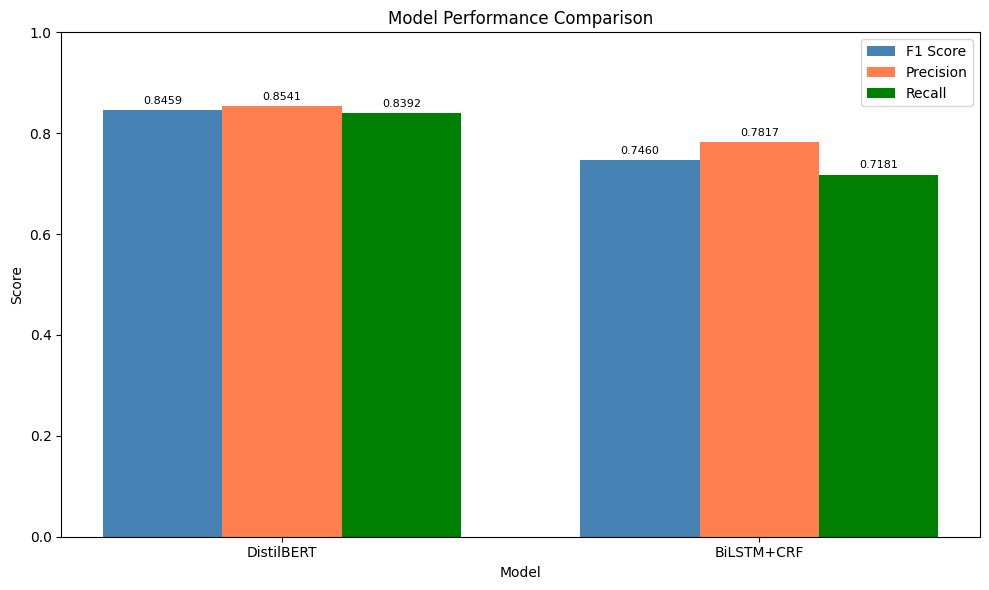


*** Winner: DistilBERT ***


In [42]:
# Model Comparison
print("="*60)
print("MODEL COMPARISON SUMMARY")
print("="*60)

comparison_df = pd.DataFrame({
    'Model': ['DistilBERT', 'BiLSTM+CRF'],
    'F1 Score': [bert_f1, bilstm_f1],
    'Precision': [bert_precision, bilstm_precision],
    'Recall': [bert_recall, bilstm_recall]
})
print(comparison_df.to_string(index=False))

# Visualization
fig, ax = plt.subplots(figsize=(10, 6))
x = np.arange(2)
width = 0.25
bars1 = ax.bar(x - width, [bert_f1, bilstm_f1], width, label='F1 Score', color='steelblue')
bars2 = ax.bar(x, [bert_precision, bilstm_precision], width, label='Precision', color='coral')
bars3 = ax.bar(x + width, [bert_recall, bilstm_recall], width, label='Recall', color='green')
ax.set_xlabel('Model')
ax.set_ylabel('Score')
ax.set_title('Model Performance Comparison')
ax.set_xticks(x)
ax.set_xticklabels(['DistilBERT', 'BiLSTM+CRF'])
ax.legend()
ax.set_ylim(0, 1)
for bars in [bars1, bars2, bars3]:
    for bar in bars:
        height = bar.get_height()
        ax.annotate(f'{height:.4f}', xy=(bar.get_x() + bar.get_width() / 2, height), xytext=(0, 3), textcoords="offset points", ha='center', va='bottom', fontsize=8)
plt.tight_layout()
plt.savefig('D:/Python/NLP/CK/charts/model_comparison.png', dpi=150)
plt.show()
winner = 'DistilBERT' if bert_f1 > bilstm_f1 else 'BiLSTM+CRF'
print(f"\n*** Winner: {winner} ***")

---
## Conclusion

In [43]:
print("="*60)
print("CONCLUSION")
print("="*60)
print(f"""
### Model Performance Summary

| Metric    | DistilBERT | BiLSTM+CRF |
|----------|-----------|------------|
| F1 Score | {bert_f1:.4f}   | {bilstm_f1:.4f}   |
| Precision| {bert_precision:.4f}   | {bilstm_precision:.4f}   |
| Recall   | {bert_recall:.4f}   | {bilstm_recall:.4f}   |

### Recommendations
- Use DistilBERT for higher accuracy
- Use BiLSTM+CRF for faster inference
- Consider ensemble for best results""")

CONCLUSION

### Model Performance Summary

| Metric    | DistilBERT | BiLSTM+CRF |
|----------|-----------|------------|
| F1 Score | 0.8459   | 0.7460   |
| Precision| 0.8541   | 0.7817   |
| Recall   | 0.8392   | 0.7181   |

### Recommendations
- Use DistilBERT for higher accuracy
- Use BiLSTM+CRF for faster inference
- Consider ensemble for best results
